# Deep Learning


# 10.1 Single Layer Neural Network

A neural network is a non linear function f(X) which predicts the response Y for a given set of predictors or features X. 

The typical structure of a feed forward model contains a input layer, where the input features are feed in, a sequence of at least 1 hidden layer with K hidden units A1 ... An, and a output layer with one or more outputs Y. 

The output can be categorical e.g. in a classification task or a quantitave response e.g. in a regression task. With this structure the network models a function 

$$
f(X) = \beta_0 + \Sigma_{k=1}^K \beta_k h_k(X) \\
= \beta_0 + \Sigma_{k=1}^K \beta_k g(\omega_{k0} + \Sigma_{j=1}^p \omega_{kj} X_j)
$$

It is build up in two steps first we have the K activations in the hidden layer, which are computed as function of the input features

$$
A_k = h_k(X)=g(\omega_{k0} + \Sigma_{j=1}^p \omega_{kj} X_j)
$$

where g(X) is a non linear activation function. The non linear activation function can be seen as a non linear transformation of the input features into a different space, similar to kernel functions in the previous section.

These K activations from the hidden layer are then feed into an output layer, resulting in 

$$
f(X) = \beta_0 + \Sigma_{k=1}^K \beta_k A_k
$$

All parameters $\beta_0, ... \beta_k$ and the weights $\omega_0 ..., \omega_k $ need to be learned from data. 

The hidden layer constructs from the 4 input features 5 new features.

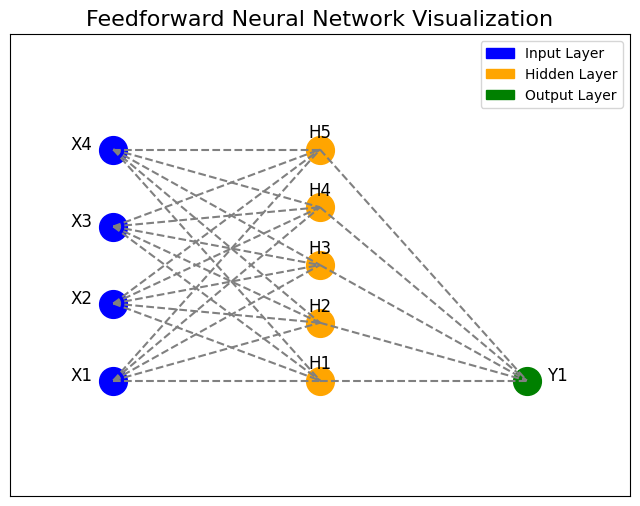

In [30]:
## Visualiyation of a feedforward neural network
## With X=4, H=5, Y=1 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
# Define the number of neurons in each layer
input_neurons = 4
hidden_neurons = 5
output_neurons = 1
# Define the positions of the neurons in each layer
input_layer_x = 0
hidden_layer_x = 1
output_layer_x = 2
input_layer_y = np.linspace(0, 1, input_neurons)
hidden_layer_y = np.linspace(0, 1, hidden_neurons)
output_layer_y = np.linspace(0, 1, output_neurons)
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot the neurons in the input layer
for i in range(input_neurons):
    ax.plot(input_layer_x, input_layer_y[i], 'o', color='blue', markersize=20)
    ax.text(input_layer_x - 0.1, input_layer_y[i], f'X{i+1}', fontsize=12, ha='right')
# Plot the neurons in the hidden layer
for i in range(hidden_neurons):
    ax.plot(hidden_layer_x, hidden_layer_y[i], 'o', color='orange', markersize=20)
    ax.text(hidden_layer_x, hidden_layer_y[i] + 0.05, f'H{i+1}', fontsize=12, ha='center')  
# Plot the neurons in the output layer
for i in range(output_neurons):
    ax.plot(output_layer_x, output_layer_y[i], 'o', color='green', markersize=20)
    ax.text(output_layer_x + 0.1, output_layer_y[i], f'Y{i+1}', fontsize=12, ha='left')
# Plot the connections between the layers
for i in range(input_neurons):
    for j in range(hidden_neurons):
        ax.plot([input_layer_x, hidden_layer_x], [input_layer_y[i], hidden_layer_y[j]], color='gray', linestyle='--')
for i in range(hidden_neurons):
    for j in range(output_neurons):
        ax.plot([hidden_layer_x, output_layer_x], [hidden_layer_y[i], output_layer_y[j]], color='gray', linestyle='--')
        
# Set the limits and labels
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Feedforward Neural Network Visualization', fontsize=16)
# Add legend
input_patch = mpatches.Patch(color='blue', label='Input Layer')
hidden_patch = mpatches.Patch(color='orange', label='Hidden Layer')
output_patch = mpatches.Patch(color='green', label='Output Layer')
plt.legend(handles=[input_patch, hidden_patch, output_patch], loc='upper right')
# Show the plot
plt.show()

## Activation functions

The activation function is a non linear function which transforms the input into a non linear output. This functions make neural networks powerfull to model non linear relationships between the inputs and the outputs.

Typical activation functions are:

### Sigmoid

$$
g(z) = \frac{1}{1+e^-z}
$$

### ReLu (Rectivy linear unit)

$$
g(z) = 0 if z<0 else z
$$

### Tanh

g(z) = tanh(z)


Aside of this activation functions there exist several further activation functions like LeakyReLu and in general the activation function is a hyperparameter which can be optimized. Without the non linear activation the model would represent just a simple linear model.


## Interaction between parameters

As depicted in the image above the network connections allow interaction between the parameters. This is a analogy to the polynomial regression models for examples where we also had for example X1X2 as mixture term to represent interaction between the parameters.

## Fitting the model parameters

Within this model class we need need to learn the bias terms $\beta$ as well as the weights $\omega$. For a regression task as described in this model the squared error loss is used and the parameters need to be choosen to minimize it. 

$$
\Sigma_{i=1}^n (y_i - f(x_i))^2
$$

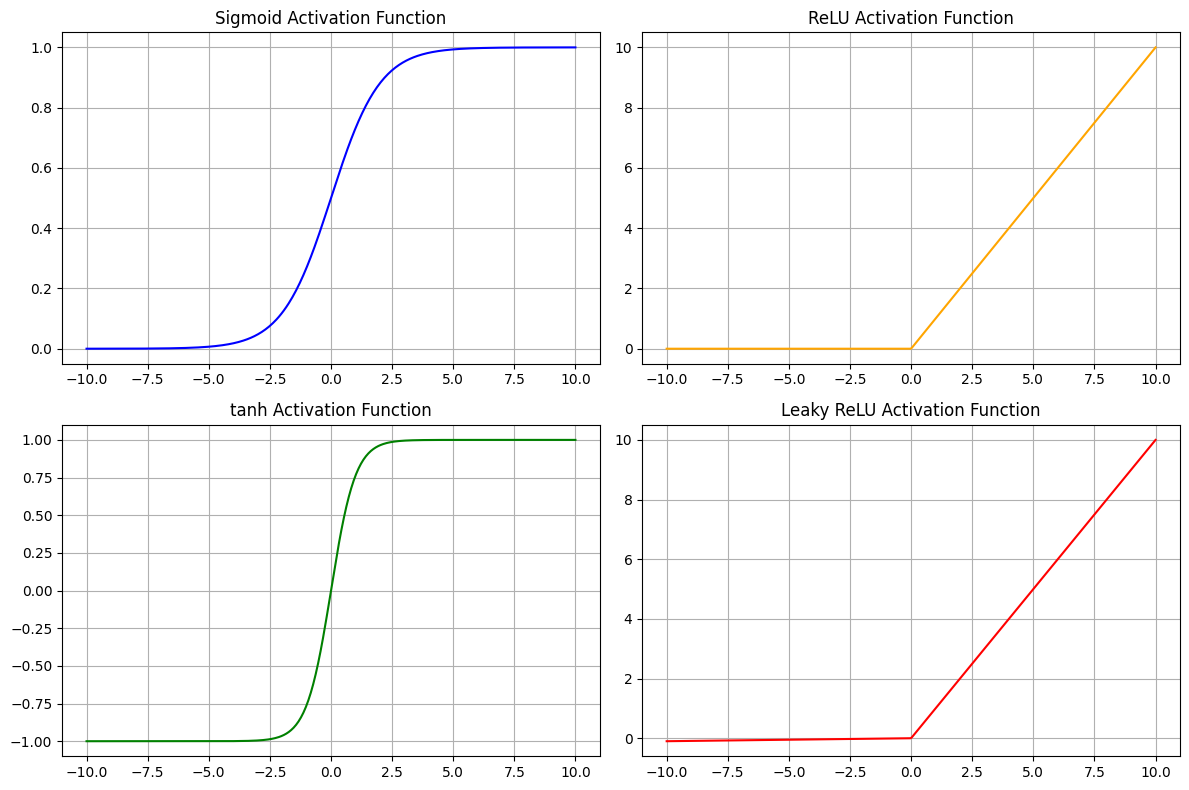

In [31]:
## lets visualize some activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLu (x):
    return np.maximum(0, x)

def tanH(x):
    return np.tanh(x)

def LeakzyReLu(x):
    return np.where(x > 0, x, 0.01 * x)

x = np.linspace(-10, 10, 400)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(x, sigmoid(x), label='Sigmoid', color='blue')
plt.title('Sigmoid Activation Function')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(x, ReLu(x), label='ReLU', color='orange')
plt.title('ReLU Activation Function')
plt.grid()
plt.subplot(2, 2, 3)
plt.plot(x, tanH(x), label='tanh', color='green')
plt.title('tanh Activation Function')
plt.grid()
plt.subplot(2, 2, 4)
plt.plot(x, LeakzyReLu(x), label='Leaky ReLU', color='red')
plt.title('Leaky ReLU Activation Function')
plt.grid()
plt.tight_layout()
plt.show()

In [32]:
## lets build the simple feedforward neural network with random weights and biases using nuymPy

import numpy as np
# Define the number of neurons in each layer
input_neurons = 4
hidden_neurons = 5
output_neurons = 1
# Initialize random weights and biases (book notation)
omega_kj = np.random.rand(input_neurons, hidden_neurons)  # input->hidden weights (omega_kj)
omega_k0 = np.random.rand(hidden_neurons)  # hidden biases (omega_k0)
beta_k = np.random.rand(hidden_neurons, output_neurons)  # output weights (beta_k)
beta_0 = np.random.rand(output_neurons)  # output bias (beta_0)

# Now we need a sigmoid activation function to introduce non-linearity
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Define the feedforward function
def feedforward(X):
    # Calculate the hidden layer activations (uses omega_kj and omega_k0)
    hidden_layer_input = np.dot(X, omega_kj) + omega_k0  # omega_k0 + sum_j omega_kj * X_j
    hidden_layer_output = sigmoid(hidden_layer_input)  # A_k = g(...)

    # Calculate the output layer activations (uses beta_k and beta_0)
    output_layer_input = np.dot(hidden_layer_output, beta_k) + beta_0  # beta_0 + sum_k beta_k * A_k
    output_layer_output = sigmoid(output_layer_input)

    return output_layer_output

# Example input vector
X = np.random.rand(input_neurons)  # Random input vector of size 4
Y_target = np.random.rand(output_neurons)  # Random target output vector of size 1
# Get the output from the feedforward function
output = feedforward(X)
print("Input X:", X)
print("Target Y:", Y_target)
print("Output from feedforward:", output)

# Loss function L2 loss
def L2_loss(Y_target, Y_pred):
    return np.sum((Y_target - Y_pred) ** 2)

# Calculate the loss
loss = L2_loss(Y_target, output)
print("L2 Loss:", loss)

Input X: [0.45328883 0.52439027 0.44076275 0.40076306]
Target Y: [0.55964033]
Output from feedforward: [0.85917325]
L2 Loss: 0.08971997077099006


## Fitting a neural network

The model we just created is missing an important piece, the capability to learn and updates its parameters from data. 

Recalling the model function 

$$
f(X) = \beta_0 + \Sigma_{k=1}^K \beta_k h_k(X) \\
= \beta_0 + \Sigma_{k=1}^K \beta_k g(\omega_{k0} + \Sigma_{j=1}^p \omega_{kj} X_j)
$$

and the minimization target (loss) function
$$
\Sigma_{i=1}^n (y_i - f(x_i))^2
$$

we essentially can fomulate a minimization problem

$$
min_{\omega_K|_1^K, \beta} \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2
$$

with the given forward function f(X). On a first glimps the objective looks simple enough but due to the symmetry in the hidden units (all inputs map to all hidden units) and the nested arrangment of the parameters $\beta and \omega$ the optimization is not straight forward and the optimizer can stuck in local minima, which means we wont find the global minima and thus the best parameter set to discriminate the data. The existence of local minima is linked to the non convex structure of the function.

In general two strategies are applied to reach the global minima (or approximate it as it cant be guaranteed that the global minima will be reached)

1. Slow Learning: Instead of trying to fit the full function in one step use a slow itterative fashion using gradient descent.
2. Regularization: Similar to the polynomial models, penalties are imposed to the model parameters e.g. lasso or ridge (See Notebook 6) to shrink the parameters and ensure better generalization


### Gradient descent to fit the model parameters

To learn the model parameters in a slow and iterative fashion gradient descent is used in neural networks. This algorithm starts with some initial guess of the model parameters (Random initialization of the weights and biases, See: Xavier initialization for sigmoid or Kaiming He initialization for ReLu) $\theta_0$ and then sucessfully update them step by step.

The algorithm works as follows
1. Random initialization of theta
2. Iterate until objective fails to decrease (Minima found)

2.1 Find a small delta of the parameters theta such that the objective reduces

2.2 Update objectives and increase epoch count



Paper initialization:
- https://arxiv.org/abs/1502.01852 --> Kaiming He
- https://proceedings.mlr.press/v9/glorot10a.html --> Xavier 



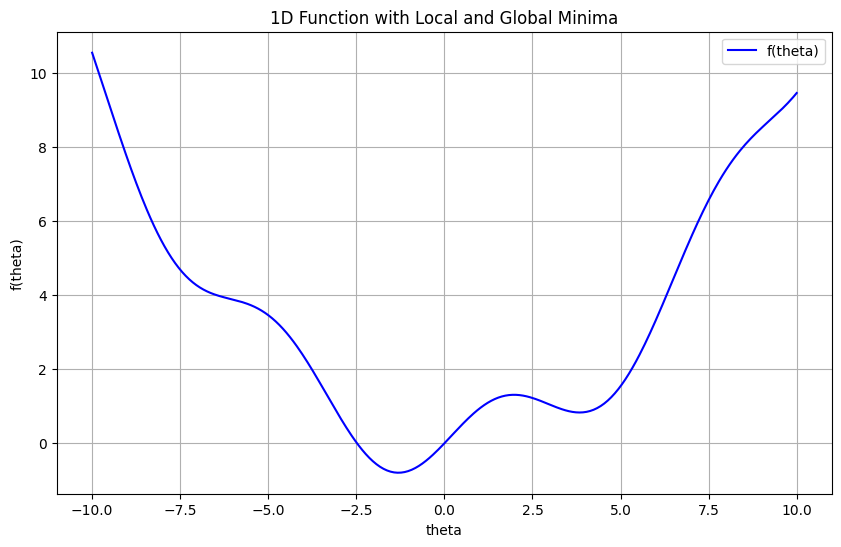

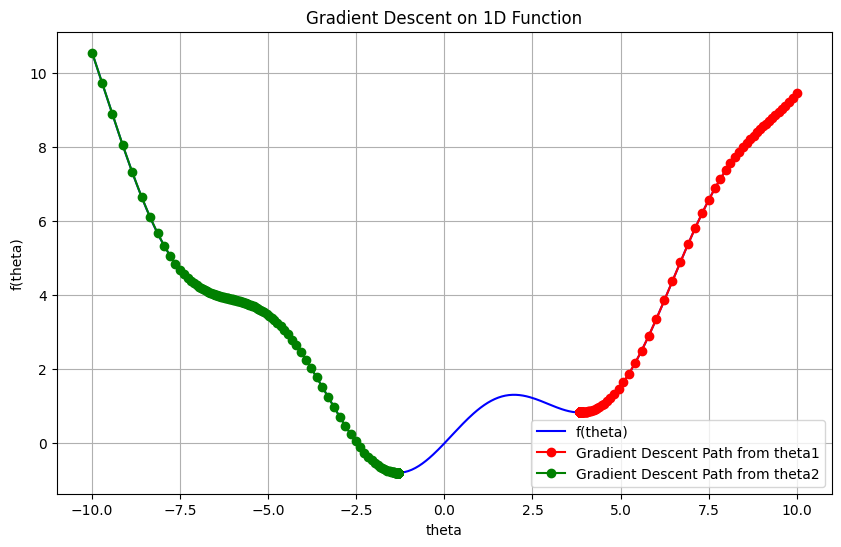

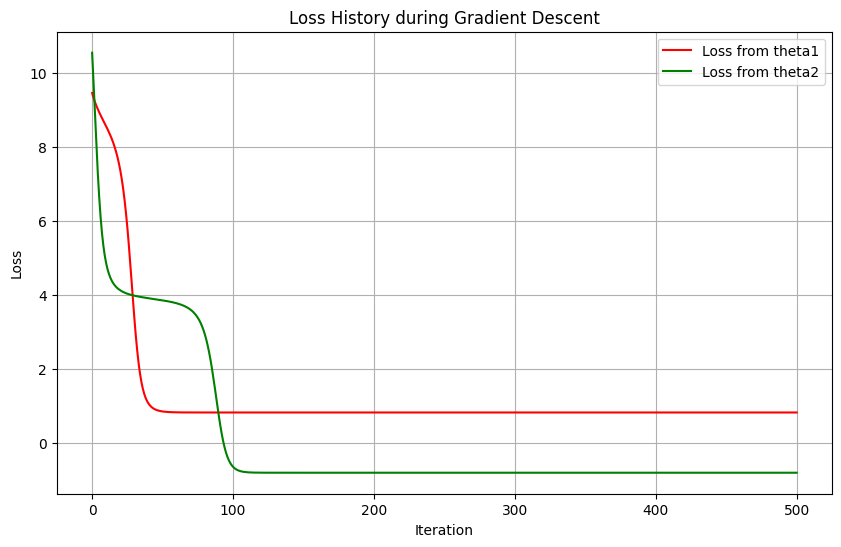

In [33]:
## Example of 1D gradient decent with local and global minima

# lets define a 1D function with a local and global minima

import numpy as np 
import matplotlib.pyplot as plt

theta_vec = np.linspace(-10, 10, 400)# create a vector of theta values from -10 to 10

def f(theta):
    return np.sin(theta) + 0.1 * theta**2  # a function with a local and global minima
plt.figure(figsize=(10, 6))
plt.plot(theta_vec, f(theta_vec), label='f(theta)', color='blue')
plt.title('1D Function with Local and Global Minima')
plt.xlabel('theta')
plt.ylabel('f(theta)')
plt.grid()
plt.legend()
plt.show()

# Now we will perform gradient descent on this function starting from a random point
theta1 = 10 # random starting point
theta2 = -10 # random starting point
# now we perform gradient descent starting from theta1 and theta2 and we will see how it converges to the local and global minima respectively
learning_rate = 0.1
num_iterations = 500
theta1_history = [theta1]
theta2_history = [theta2]
loss1_history = [f(theta1)]
loss2_history = [f(theta2)]
for i in range(num_iterations):
    # Calculate the gradient (numerical approximation)
    epsilon = 1e-5
    grad1 = (f(theta1 + epsilon) - f(theta1 - epsilon)) / (2 * epsilon)
    grad2 = (f(theta2 + epsilon) - f(theta2 - epsilon)) / (2 * epsilon)
    
    # Update theta using gradient descent
    theta1 -= learning_rate * grad1
    theta2 -= learning_rate * grad2
    
    # Store history for visualization
    theta1_history.append(theta1)
    theta2_history.append(theta2)
    loss1_history.append(f(theta1))
    loss2_history.append(f(theta2))
# Plot the function and the path taken by gradient descent
plt.figure(figsize=(10, 6))
plt.plot(theta_vec, f(theta_vec), label='f(theta)', color='blue')
plt.plot(theta1_history, loss1_history, marker='o', color='red', label='Gradient Descent Path from theta1')
plt.plot(theta2_history, loss2_history, marker='o', color='green', label='Gradient Descent Path from theta2')
plt.title('Gradient Descent on 1D Function')
plt.xlabel('theta')
plt.ylabel('f(theta)')
plt.grid()
plt.legend()
plt.show()


# now plot the loss history to see how it converges
plt.figure(figsize=(10, 6))
plt.plot(loss1_history, label='Loss from theta1', color='red')
plt.plot(loss2_history, label='Loss from theta2', color='green')
plt.title('Loss History during Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()




## Backpropagation
What we missed for now is how to find the direction in which we should make the step. In the previous section we phrased it "In the direction where the objective minimizes". To find this direction we take the first partial derivative of the objective function $R(\theta)$

$$
\nabla R(\theta) = \frac{\delta R(\theta)}{\delta \theta}|_{\theta = \theta_m}
$$

$\theta = \theta_m$ means we evaluate the derivative at the current guess $\theta_m$. Then the derivative will give us the direction where $R(\theta )$ increases most rapidly and we move theta then by a step controlled by the learning rate in the opposite direction. If we do this procedure of calculating derivatives and updating theta, the gradients can become 0 which indicates that we reached a minimum.

Recalling our initial minimization goal

$$
min_{\omega_K|_1^K, \beta} \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2
$$
we can write 
$$
R(\theta) \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2
$$

where $\theta$ contains all weight and bias terms of the model$

Since R is a sum over all our labeled observations we can calculate the gradients for each observation and label individually and sum up the total loss afterwards.

$$
R_i = \frac{1}{2} (y_i - \beta_0 - \Sigma_{k=1}^K \beta_k g(\omega_{k0}+ \Sigma_{j=1}^p \omega_{kj}))^2
$$

To simplify the term we substitute the second therm with $z_k = \omega_{k0}+ \Sigma_{j=1}^p \omega_{kj}$ and then take the partial derivative with respect to $\beta_k$

$$
\frac{\delta R(\theta_i)}{\delta \beta_k} = -(y_i - f_\theta(x_i))g(z_{ik})
$$

and with respect to $\omega_{kj}$

$$
\frac{\delta R(\theta_i)}{\delta \omega_{kj}} = -(y_i - f_\theta(x_i)) \beta_k g'(z_{ik})x_{ij}.
$$

Both terms contain the residual $-(y_i - f_\theta(x_i))$. The upper term attributes a part of the residual to the model parameters of the hidden units with the value of g(z_{ik}) and the lower term shows that a part of the residuals is attributed to the input j via hidden unit k. Therefore we propagate the errors back through the model and assign a fraction of the residual to each unit of the model. This process is called backpropagation and the working horse for modern AI. Calculating the gradients and performing the updates requires a solid implementation of the algorithm and tight bookkeeping of the values. Therefore it is recommend to stick to modern deep learning libraries which take care of it.



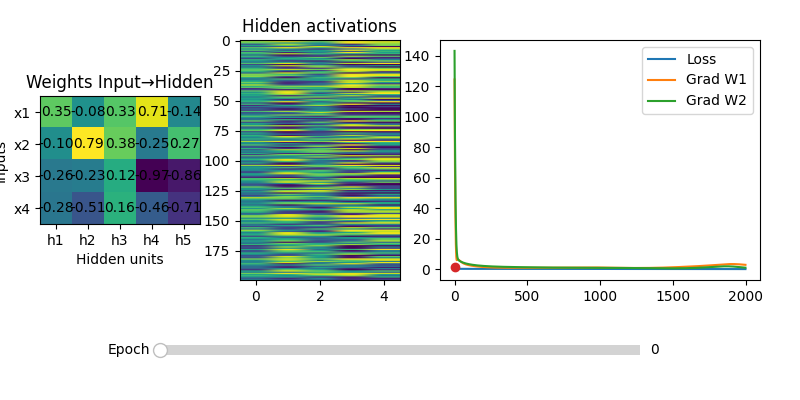

C:\Users\Johannes\AppData\Local\Temp\ipykernel_1300\1050589539.py:207: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grid[j,i]=z


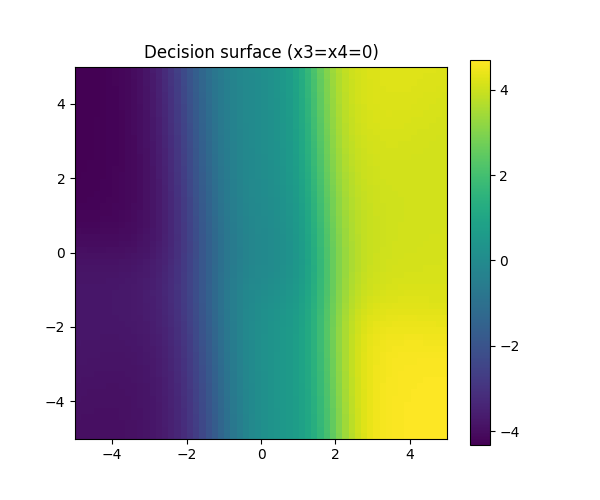

Test MSE: 1354.325746104942


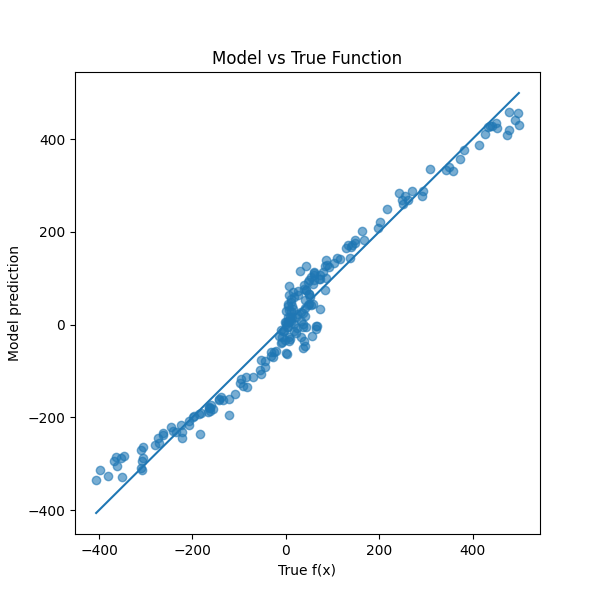

In [34]:
# =========================
# Backprop Demo 
# =========================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import matplotlib
%matplotlib widget
np.random.seed(42)

# -----------------
# Architektur
# -----------------
input_neurons = 4
hidden_neurons = 5
output_neurons = 1

# -----------------
# Aktivierungen
# -----------------
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(a):
    return a*(1-a)

def tanh(x):
    return np.tanh(x)

def tanh_deriv(a):
    return 1 - a**2

# -----------------
# Xavier Init
# -----------------
W1 = np.random.randn(input_neurons, hidden_neurons)/np.sqrt(input_neurons)
b1 = np.zeros(hidden_neurons)
W2 = np.random.randn(hidden_neurons, output_neurons)/np.sqrt(hidden_neurons)
b2 = np.zeros(output_neurons)

def draw_weight_labels(ax, W, prefix_x="x", prefix_h="h"):
    ax.clear()

    im = ax.imshow(W)

    # Ticks setzen
    ax.set_xticks(np.arange(W.shape[1]))
    ax.set_yticks(np.arange(W.shape[0]))

    ax.set_xticklabels([f"{prefix_h}{j+1}" for j in range(W.shape[1])])
    ax.set_yticklabels([f"{prefix_x}{i+1}" for i in range(W.shape[0])])

    ax.set_xlabel("Hidden units")
    ax.set_ylabel("Inputs")

    # Text in jede Zelle
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            ax.text(j, i,
                    f"{W[i,j]:.2f}",
                    ha="center", va="center")

    return im

# -----------------
# Datensatz
# -----------------

def true_function(X):
    Y = 4*X[:,0]**3 + 3*X[:,1]**2 - .1*X[:,2] + 0.1*X[:,3]
    return Y.reshape(-1,1)
def generate_dataset(n):
    X = np.random.rand(n, input_neurons)*10 - 5
    Y = true_function(X)
    return X, Y

X_train, Y_train = generate_dataset(200)

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
X_train_n = (X_train - X_mean) / X_std
Y_mean, Y_std = Y_train.mean(), Y_train.std()
Y_train_n = (Y_train - Y_mean)/Y_std
# -----------------
# Forward / Loss
# -----------------
def forward(X, params):
    W1,b1,W2,b2 = params
    Z1 = X@W1 + b1
    A1 = tanh(Z1)
    Z2 = A1@W2 + b2  # linear output
    return Z1,A1,Z2

def loss_fn(y, yhat):
    return np.mean((y-yhat)**2)

# -----------------
# Train Step
# -----------------
def train_step(X,y,params,lr):
    W1,b1,W2,b2 = params

    Z1,A1,Z2 = forward(X,params)
    loss = loss_fn(y,Z2)

    dZ2 = (Z2-y)
    dW2 = A1.T@dZ2
    db2 = dZ2.sum(axis=0)

    dZ1 = (dZ2@W2.T)*tanh_deriv(A1)
    dW1 = X.T@dZ1
    db1 = dZ1.sum(axis=0)

    gnorm1 = np.linalg.norm(dW1)
    gnorm2 = np.linalg.norm(dW2)

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

    return loss,(W1,b1,W2,b2),A1,gnorm1,gnorm2

# -----------------
# Training
# -----------------
params=(W1,b1,W2,b2)
epochs=2000
lr=1E-3

hist={"loss":[],"A1":[],"W1":[],"W2":[],"g1":[],"g2":[]}

for e in range(epochs):
    loss, params, A1, g1, g2 = train_step(X_train_n, Y_train_n, params, lr)

    hist["loss"].append(loss)
    hist["A1"].append(A1.copy())
    hist["W1"].append(params[0].copy())
    hist["W2"].append(params[2].copy())
    hist["g1"].append(g1)
    hist["g2"].append(g2)

   # print(f"Epoch {e+1}/{epochs}  Loss={loss:.4f}")

# -----------------
# Arrays
# -----------------
W1_hist=np.array(hist["W1"])
W2_hist=np.array(hist["W2"])
A1_hist=np.array(hist["A1"])
loss_hist=np.array(hist["loss"])
g1=np.array(hist["g1"])
g2=np.array(hist["g2"])

# -----------------
# Interaktive Visualisierung
# -----------------
fig=plt.figure(figsize=(8,4))

ax_w1=plt.axes([0.05,0.3,0.2,0.6])
ax_act=plt.axes([0.3,0.3,0.2,0.6])
ax_loss=plt.axes([0.55,0.3,0.4,0.6])
ax_slider=plt.axes([0.2,0.1,0.6,0.05])

epoch0=0

im_w1 = draw_weight_labels(ax_w1, W1_hist[epoch0])
ax_w1.set_title("Weights Input→Hidden")

im_act=ax_act.imshow(A1_hist[epoch0],aspect="auto")
ax_act.set_title("Hidden activations")

ax_loss.plot(loss_hist,label="Loss")
ax_loss.plot(g1,label="Grad W1")
ax_loss.plot(g2,label="Grad W2")
marker,=ax_loss.plot(epoch0,loss_hist[epoch0],marker="o")
ax_loss.legend()

slider=Slider(ax_slider,"Epoch",0,epochs-1,valinit=0,valstep=1)

def update(val):
    e = int(slider.val)

    draw_weight_labels(ax_w1, W1_hist[e])
    im_act.set_data(A1_hist[e])
    marker.set_data([e],[loss_hist[e]])

    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

# -----------------
# Decision Surface (2D Slice)
# -----------------
def decision_surface(params):
    W1,b1,W2,b2=params
    xs=np.linspace(-5,5,60)
    ys=np.linspace(-5,5,60)
    grid=np.zeros((60,60))

    for i,x in enumerate(xs):
        for j,y in enumerate(ys):
            inp=np.array([[x,y,0,0]])
            _,_,z=forward(inp,params)
            grid[j,i]=z

    plt.figure(figsize=(6,5))
    plt.imshow(grid,extent=[-5,5,-5,5],origin="lower")
    plt.title("Decision surface (x3=x4=0)")
    plt.colorbar()
    plt.show()

decision_surface(params)


def model_function(X, params, Y_mean, Y_std):
    _, _, y_pred_norm = forward(X, params)
    return y_pred_norm * Y_std + Y_mean




# Target-Standardisierung (wichtig)
Y_mean, Y_std = Y_train.mean(), Y_train.std()
Y_train_n = (Y_train - Y_mean)/Y_std


Y_true = true_function(X_train)
Y_pred = model_function((X_train - X_mean)/X_std, params, Y_mean, Y_std)

mse = np.mean((Y_true - Y_pred)**2)
print("Test MSE:", mse)

plt.figure(figsize=(6,6))
plt.scatter(Y_true, Y_pred, alpha=0.6)
plt.plot([Y_true.min(), Y_true.max()],
         [Y_true.min(), Y_true.max()])
plt.xlabel("True f(x)")
plt.ylabel("Model prediction")
plt.title("Model vs True Function")
plt.show()


## Regularization and Stochastic Gradient Descent

### Stochastic gradient descent and mini batch gradient descent

**Gradient descent** takes usually many steps until it converges towards a local minimum (See the first example on gradient descent on the 1D function). This steps are also called epochs in the deep learning literature. As we saw in the previous formula for the calculation of backpropagation we need to perform the forward path over all i=1 ... n observations to obtain $f\theta_i(x_i)$ to calculate our objective $(x_i - f\theta_i(x_i) )$ which we want to minimize over all our samples n. Therefore for the full gradient descent or batch gradient descent, which uses the full batch of data, we need to have to carry out a full forward path of all n samples with the current model parameters $\theta_i$, then calculate exact one set of gradients using backpropagation to finally update the model parameters according to their gradients. 

This is computational demanding and thus a less accurate (higher variance) variant of the batch gradient descent, is the **stochastic gradient descent** approach. Here randomly normal distributed one sample out of n is drawn without replacement per weight update, feed forward through the model, gradients are calculated and the model parameters are updated. This is repeated until all samples are drawn for this epoch before the next epoch starts. For a dataset of size $n$ this means $n$ updates of the model parameters $\theta$ per epoch, leading to many but noisy updates, which has one interesting property. Due to the noise this approach is capable to escape shallow local minima or saddle points in the optimization function, which makes convergence less smooth but allows to escape local minima due to the noise introduction. 

The most common resent approach used in training modern deep neural network is the **mini batch gradient descent approach**. It uses a small batch $B$ out of the n samples to calculate the gradients and perform a update of the model parameters. For all samples in $B$ the observations are forwarded through the model, the batch loss is calculated and the gradients are calculated and finally the model parameters are updated. The split of the full dataset into mini batches has also an advantage with respect to computational speed as the smaller batches allow to be stored on the cache memory of the CPU or on the memory of a graphics card to speed up the training procedure. 

### Overview table

| Method | Data Used per Update | Updates per Epoch | Gradient Variance | Computational Speed | Typical Use |
|--------|---------------------|------------------|------------------|--------------------|-------------|
| Batch GD | All $N$ samples | $1$ | Very low | Slow | Small datasets, theoretical analysis |
| SGD | $1$ sample | $N$ | Very high | Fast | Online learning, noisy optimization |
| Mini-Batch GD | $B$ samples | $N/B$ | Medium | Fast and stable | Default in deep learning |

###  Key Takeaways
 - Backpropagation computes **layer-by-layer gradients** using the chain rule 
 - Gradient descent variants differ only in **how much data is used per update** 
 - Mini-batch GD is the standard in practice 
 - SGD noise can improve generalization and exploration of the loss landscape

## Regularization

As we learned in chapter 6 by introduction of regularization we can reduce overfitting of models by shrinking the model weights $\theta$ and thus discouraging over complex models. This concept can be also used in deep neural networks by expanding the loss function with a regularization term that contains the magnitude of the model parameters. 
$$
R(\theta, \lambda) \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2 + \lambda \Sigma_{j} \theta_j^2
$$
with $\lambda$ is a controllable hyperparameter set to a small value and can be optimized based on a validation set.

### Gradient Effect
 The gradient update becomes
  $$ 
  \theta \leftarrow \theta - \eta \left( \nabla_\theta \mathcal{L} + 2\lambda \theta \right) 
  $$
This is often referred to as **weight decay** in deep learning.

### Summary on L1 and L2 normalization

| Regularization | Penalty | Effect on Weights | Typical Use |
|---|---|---|---|
| L2 | $ \sum \theta_j^2 $ | Shrinks weights smoothly | Default in neural networks |
| L1 | $ \sum abs(\theta_j) $ | Produces sparse weights | Feature selection |

## Further regularization methods
Regularization is not limited to adding penalty terms such as L1 or L2 to the loss function. In modern neural networks, **training procedures themselves** often act as regularizers by limiting effective model capacity or introducing stochasticity into the optimization process. The following regularization methods namely dropout, early stopping, and mini-batch SGD (as introduced earlier) can all be understood through the **bias–variance trade-off** and their effect on the optimization landscape.

# 1. Dropout
Dropout randomly removes (sets to zero) a subset of hidden units during each training iteration. This means the network effectively trains a **different subnetwork** on every forward pass. Let the activation vector in layer $l$ be $a^{(l)}$. We sample a mask
 $$
  m^{(l)} \sim \text{Bernoulli}(p) 
 $$
and compute 
$$ 
\tilde{a}^{(l)} = m^{(l)} \odot a^{(l)}
$$
where $p$ is the probability of **keeping** a neuron active. By randomly deactivating neurons, dropout prevents the network from relying too heavily on any single feature or pathway. Instead of learning a single complex model, the network learns an **ensemble of many simpler models** that share parameters. At test time, we use the full network but scale activations by $p$, which approximates averaging predictions across these subnetworks.  This slightly increases bias (model is noisier during training) but strongly reduces variance, which improves generalization. Dropout is particularly effective in large networks where overfitting arises from highly co-adapted features.

# 2. Early Stopping
Early stopping monitors performance on a validation set during training and halts optimization when validation error begins to increase.  During gradient descent overfitting happens due to the following reasons:
 1. Early iterations capture **large-scale structure** in the data 
 2. Later iterations begin fitting **noise and idiosyncrasies** 
 This produces the classic behavior:
 - Training error decreases monotonically
 - Validation error decreases, then increases Stopping at the minimum validation error selects a model with better generalization.
Early stopping can be interpreted as constraining the magnitude of parameters. For linear models, it can be shown that **early stopping behaves similarly to L2 regularization**, because limited optimization time prevents parameters from growing large. This prevents variance from growing excessively and keeps model in a region of moderate complexity.

# 3. Mini-Batch SGD as Implicit Regularization
In mini-batch gradient descent, the gradient is computed from a random subset of data: 
$$
g_B = \frac{1}{B} \sum_{i \in B} \nabla_\theta \mathcal{L}(x_i,\theta) 
$$
This is a **noisy estimate** of the true gradient:
$$ 
g_B = g + \epsilon 
$$ 
where $g$ is the full-dataset gradient and $\epsilon$ is stochastic noise
Modern deep networks have highly non-convex loss surfaces with:
- Sharp minima (narrow valleys)
- Flat minima (wide basins)
The noise introduced by SGD tends to push parameters away from sharp minima and toward flatter regions, which are associated with better generalization. Therefore mini-batch SGD acts similarly to adding noise to the optimization dynamics, which limits overfitting, prevents overly precise fitting of training data and improves robustness of the model. This is why SGD is often described as **implicit regularization** — the regularization arises from the algorithm itself rather than an explicit penalty term.

# Key Takeaway
 Regularization in deep learning is not just about modifying the loss function and adding a L1 or L2 regularization. The **training dynamics themselves** play a crucial role in controlling model complexity and generalization performance.



## Additional Regularization Techniques (Deep Learning)

![Regularization Taxonomy](./Images\RegularizationTechniques.png)

- **Data Augmentation** – Increases the effective training set via label-preserving transformations, improving invariance and reducing overfitting.  
- **Dropout Variants (e.g., SpatialDropout, DropConnect)** – Extend standard dropout by randomly removing entire feature maps or weight connections during training.  
- **Batch Normalization (as a regularizer)** – The stochasticity of batch statistics introduces noise that often improves generalization in addition to stabilizing optimization.  
- **Label Smoothing** – Replaces hard one-hot targets with slightly smoothed distributions to prevent over-confident predictions.  
- **Stochastic Depth / Layer Drop** – Randomly skips whole layers (often residual blocks) during training, acting like an ensemble of shallower networks.  
- **Mixup / CutMix** – Generates virtual training examples by combining inputs and labels, encouraging smoother decision boundaries.  
- **Weight Sharing / Parameter Tying** – Reduces effective model complexity by constraining parameters to be shared across structures.  
- **Spectral Normalization** – Controls the Lipschitz constant of layers by normalizing the largest singular value of weight matrices.  
- **Sharpness-Aware Minimization (SAM)** – Optimizes parameters toward flat minima that are more robust to perturbations.  
- **Knowledge Distillation** – Trains a smaller student model on soft targets from a teacher model to transfer inductive biases.  


## Multi Layer Neural Networks

Modern neural networks have ways more then the one hidden layer and often many units per layer to approximate most functions or complex relationships between the inputs and outputs. To investigate the properties of this deeper networks we will make use of the MNIST dataset, a popular dataset to demonstrate the capability of deep neural networks. It contains images of size 28x28 with handwritten digits from 0-9. In total there a 70.000 examples including their labels and the target is now to train a neural network to predict the probability which number is on the image and finally predict the number (the one with the highest probability). 

For this purpose we introduce **One Hot Encoding** to represent the potential labels 0-9 by a 10 element long target vector where all elements are 0 except the index of the number, which is displayed on that image. A 7 is therefore represented by the vector $[0,0,0,0,0,0,0,1,0,0]$. This one hot encoding also forces the model to handle a multi task problem as it needs to output a probability for all this classes.

Furthermore we need to change to a different loss function which is capable to deal with categorical features like this as we have encoded the labels in a categoric manner. This loss function is called **Cross Entropy Loss** 
$$
-\Sigma_{i=1}^n\Sigma_{m=0}^9y_{im}log(f_m(x_i))
$$
This loss function is also known as the negative multinomial log-likelyhood. The function within the $f_m(x_i)$ loss term is the softmax function which represents the class propability   $f_m(X) =P_r(Y = m|X) = \frac{e^Z_m}{\Sigma_{l=0}^9 e^Z_l}$ as we used it also in logistic regression. 

To build this model we will use pytorch, one of the most used python package to build, train and optimize neural networks. 

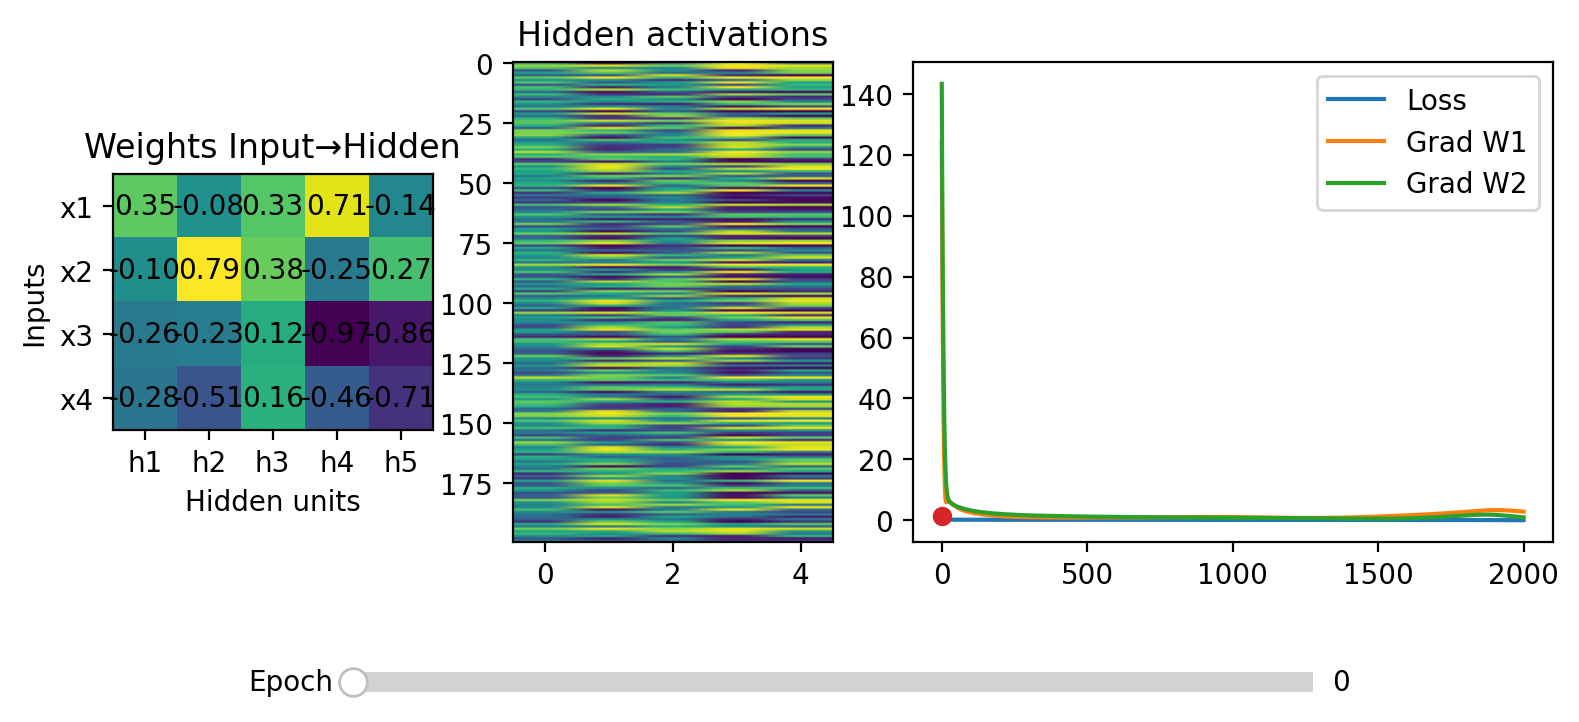

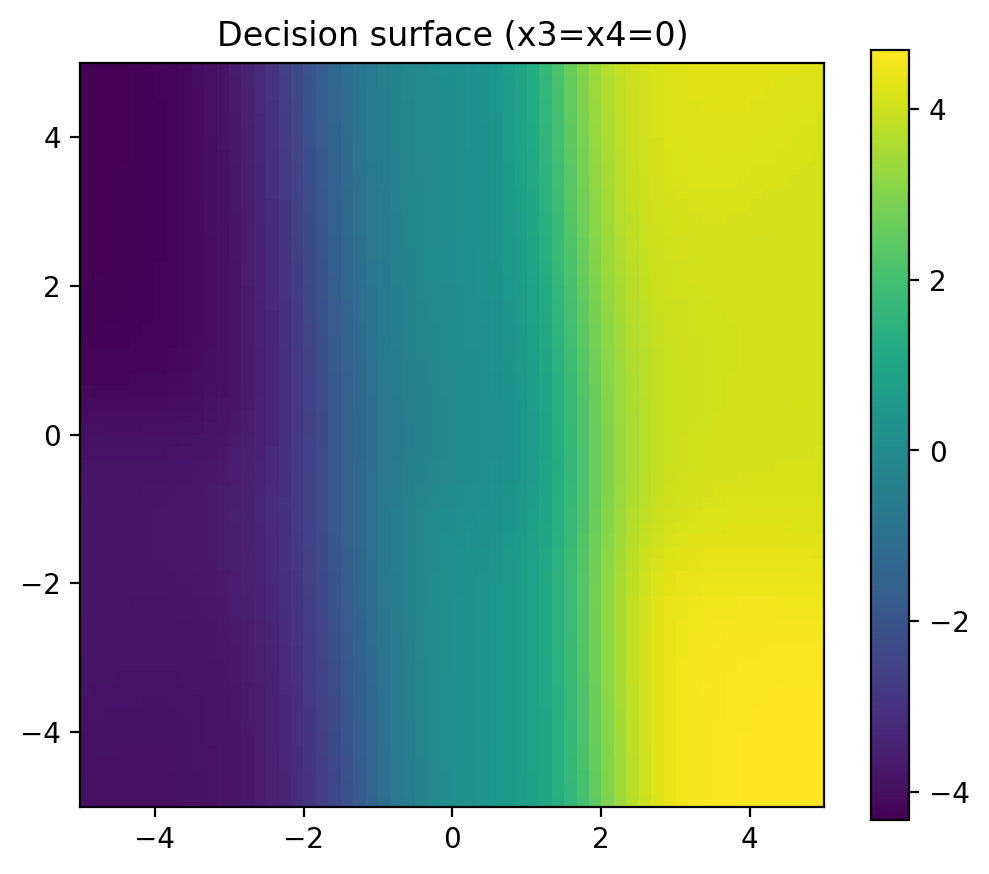

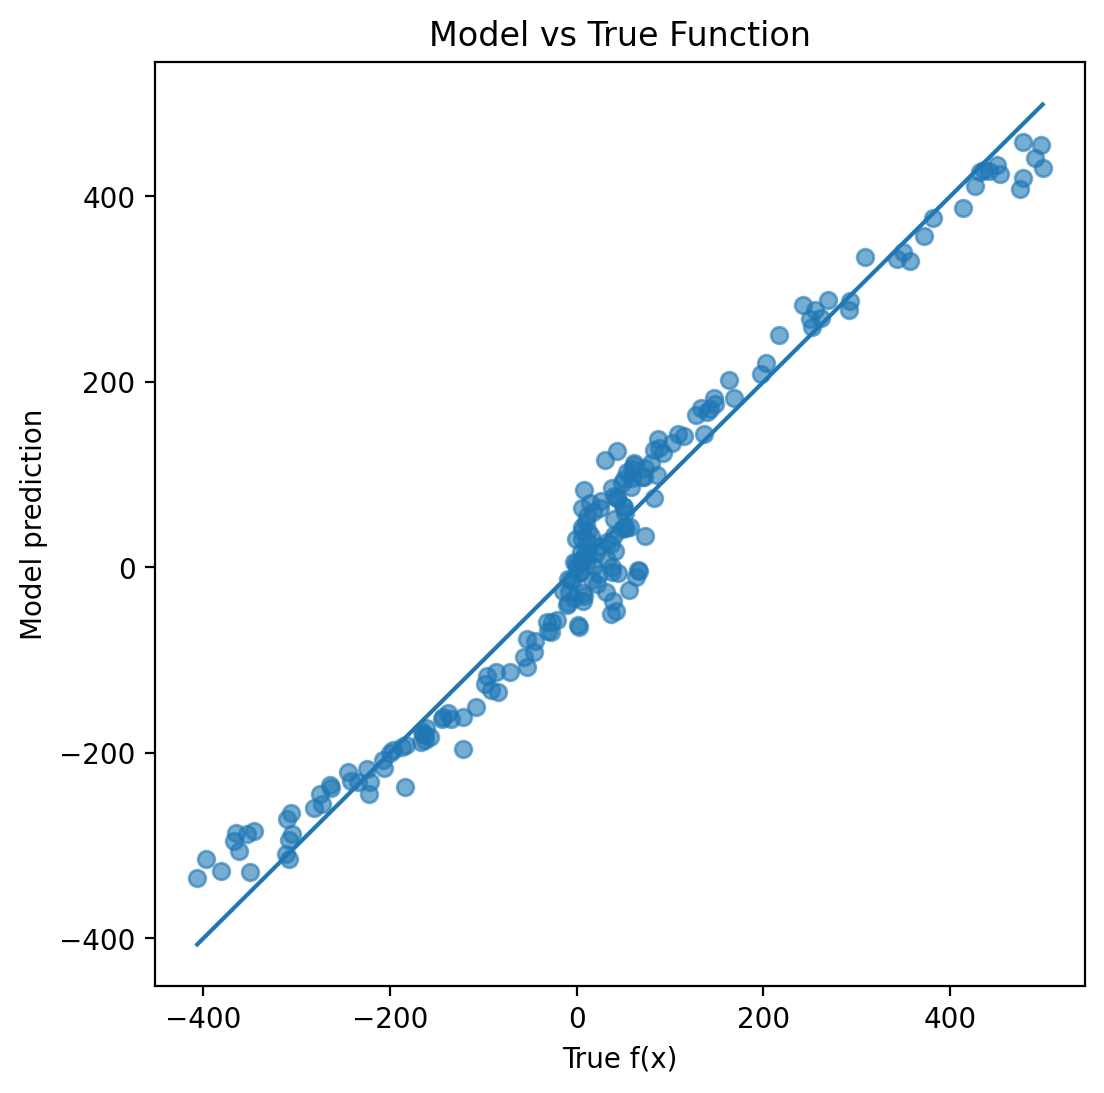

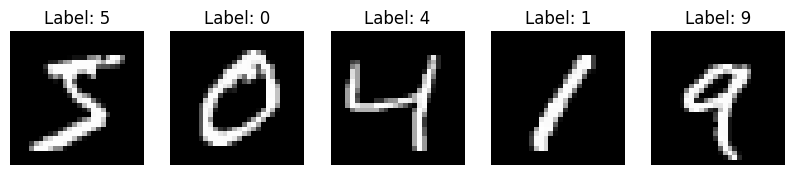

Train dataset size: 60000
Test dataset size: 10000
Using device: cuda
Epoch [1/5], Loss: 1.5982
Validation Loss: 1.5283, Accuracy: 0.9365
Epoch [2/5], Loss: 1.5175
Validation Loss: 1.5078, Accuracy: 0.9547
Epoch [3/5], Loss: 1.5039
Validation Loss: 1.4991, Accuracy: 0.9637
Epoch [4/5], Loss: 1.4959
Validation Loss: 1.4940, Accuracy: 0.9683
Epoch [5/5], Loss: 1.4908
Validation Loss: 1.4986, Accuracy: 0.9631


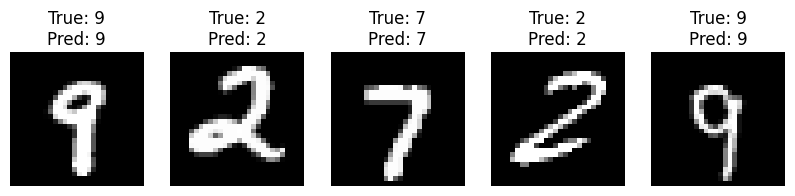

In [35]:
## Pytorch implementation of a deep feed forward neural network for the MNIST dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
%matplotlib inline
#1. load and display the MNIST dataset

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor()) # train dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor()) # test dataset

# Display some samples from the dataset
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.show()

# print size of the datasets
print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

#2. Define a deep feedforward neural network
class DeepNN(nn.Module):
    def __init__(self):
        super(DeepNN, self).__init__()
        self.flatten = nn.Flatten()  # flatten the 28x28 images to a 784 vector
        self.fc1 = nn.Linear(28*28, 256)  # first hidden layer with 256 neurons
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)  # second hidden layer with 128 neurons
        self.relu2 = nn.ReLU()
        self.fc4 = nn.Linear(128, 10)    # output layer with 10 neurons (for the 10 classes)
        self.softmax = nn.Softmax(dim=1)  # softmax activation for the output layer

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc4(x)
        x = self.softmax(x)
        return x


#3. Train the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # use GPU if available
print(f'Using device: {device}')

model = DeepNN().to(device)
criterion = nn.CrossEntropyLoss()  # loss function for multi-class classification 
optimizer = optim.Adam(model.parameters(), lr=0.001)  # optimizer for training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # data loader for training with a mini/batch of size 64 stochastic gradient descent
val_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)  # data loader for validation/testing
num_epochs = 5 # number of epochs for training
for epoch in range(num_epochs):
    model.train()  # set the model to training mode
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # move data to the device (GPU or CPU)
        optimizer.zero_grad()  # zero the parameter gradients
        outputs = model(images)  # forward pass
        loss = criterion(outputs, labels)  # compute the loss
        loss.backward()  # backward pass
        optimizer.step()  # update the weights
        running_loss += loss.item() * images.size(0)  # accumulate the loss

    epoch_loss = running_loss / len(train_loader.dataset)  # average loss for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

    # Validation phase
    model.eval()  # set the model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # disable gradient calculation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy = correct / total
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}')
    
    
# 4. Test the model on some test samples
model.eval()  # set the model to evaluation mode
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)  # data loader for testing with a mini/batch of size 5
with torch.no_grad():  # disable gradient calculation for testing
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Display the test samples and their predicted labels
        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[i].set_title(f'True: {labels[i].item()}\nPred: {predicted[i].item()}')
            axes[i].axis('off')
        plt.show()
        break  # only display one batch of test samples

In [36]:
# Now lets train the model for 20 epochs and different regularization techniques and compare the results
# 1) Ridge regression (L2 regularization)
# 2) Lasso regression (L1 regularization)
# 3) Dropout regularization



# Then show the performance compared to Multinomial logistic regression and LDA (Linear Discriminant Analysis)


# lets start with L2 regularization (Ridge regression)
class DeepNN_L2(nn.Module):
    def __init__(self, l2_lambda=1E-6):
        super(DeepNN_L2, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)
        self.l2_lambda = l2_lambda

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x
    
    def l2_regularization(self):
        l2_reg = 0
        for param in self.parameters():
            l2_reg += torch.norm(param)
        return self.l2_lambda * l2_reg
# Now we will train this model with L2 regularization and compare the results to the original model without regularization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model_l2 = DeepNN_L2(l2_lambda=1E-6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_l2.parameters(), lr=0.001)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
num_epochs = 5
for epoch in range(num_epochs):
    model_l2.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_l2(images)
        loss = criterion(outputs, labels) + model_l2.l2_regularization()  # add L2 regularization to the loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

    # Validation phase
    model_l2.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_l2(images)
            loss = criterion(outputs, labels) # + model_l2.l2_regularization()  # add L2 regularization to the validation loss
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy = correct / total
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}')
    
# Show final performance of the L2 regularized model on the test set
model_l2.eval()
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_l2(images)
        _, predicted = torch.max(outputs, 1)

        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[i].set_title(f'True: {labels[i].item()}\nPred: {predicted[i].item()}')
            axes[i].axis('off')
        plt.show()
        break
    
# Now we will implement L1 regularization (Lasso regression) and compare the results to the original model and the L2 regularized model
class DeepNN_L1(nn.Module):
    def __init__(self, l1_lambda=1E-6):
        super(DeepNN_L1, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)
        self.l1_lambda = l1_lambda

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x
    
    def l1_regularization(self):
        l1_reg = 0
        for param in self.parameters():
            l1_reg += torch.sum(torch.abs(param))
        return self.l1_lambda * l1_reg
# Now we will train this model with L1 regularization and compare the results to the original model and the L2 regularized model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model_l1 = DeepNN_L1(l1_lambda=1E-6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_l1.parameters(), lr=0.001)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
num_epochs = 5
for epoch in range(num_epochs):
    model_l1.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_l1(images)
        loss = criterion(outputs, labels) + model_l1.l1_regularization()  # add L1 regularization to the loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

    # Validation phase
    model_l1.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_l1(images)
            loss = criterion(outputs, labels) #+ model_l1.l1_regularization()  # add L1 regularization to the validation loss
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy = correct / total
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}')
# Show final performance of the L1 regularized model on the test set
model_l1.eval()
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_l1(images)
        _, predicted = torch.max(outputs, 1)

        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[i].set_title(f'True: {labels[i].item()}\nPred: {predicted[i].item()}')
            axes[i].axis('off')
        plt.show()
        break
    
    
# now lets implement dropout regularization and compare the results to the original model and the L1 and L2 regularized models
class DeepNN_Dropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DeepNN_Dropout, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)  # dropout layer after the first hidden layer
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)  # dropout layer after the second hidden layer
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)  # apply dropout after the first hidden layer
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)  # apply dropout after the second hidden layer
        x = self.fc3(x)
        return x
# Now we will train this model with dropout regularization and compare the results to the original model and the L1 and L2 regularized models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model_dropout = DeepNN_Dropout(dropout_rate=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropout.parameters(), lr=0.001)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
num_epochs = 5
for epoch in range(num_epochs):
    model_dropout.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_dropout(images)
        loss = criterion(outputs, labels)  # dropout is applied during training, so we don't need to add it to the loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

    # Validation phase
    model_dropout.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_dropout(images)
            loss = criterion(outputs, labels)  # dropout is not applied during evaluation, so we don't need to add it to the validation loss
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy = correct / total
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}')
# Show final performance of the dropout regularized model on the test set
model_dropout.eval()
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_dropout(images)
        _, predicted = torch.max(outputs, 1)

        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[i].set_title(f'True: {labels[i].item()}\nPred: {predicted[i].item()}')
            axes[i].axis('off')
        plt.show()
        break

Using device: cuda


KeyboardInterrupt: 

# Convolutional Neural Networks

So far we used a multi layer fully connected neural network to predict the handwritten digits on the mnist dataset. The main idea was to flatten the 2D images into a 1D feature vector and us this as a huge 1D input vector for the neural network. The main drawback of flattening the vector is that we to some extent remove the local structure of the digits like the local positions of bright and dark pixels in the 2D image. 

Convolution neural networks address this limitation by introducing a different model architecture inspired by the convolution kernel, known from image processing. 

A convolution kernel is a tiny e.g. 3x3 matrix of weights and the convolution operator denoted as * is used to fold the kernel with the input image.

The following example shows what happens if we apply a convolution kernel with different kernel structures to an image from MNIST.

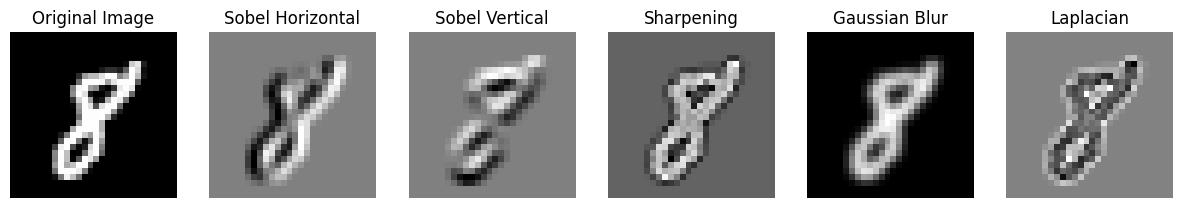

In [ ]:
## Example of different convolution kernels and their effects on an image
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
%matplotlib inline
# load a "8" image from the MNIST dataset
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
# get the first image of the dataset which is an "8"
for i in range(len(mnist)):
    image, label = mnist[i]
    if label == 8:
        img = image.squeeze().numpy()
        break
# Define different convolution kernels
# start with a simple edge detection kernel (also known as the Sobel operator) for horizontal edges and vertical edges
sobel_horizontal = np.array([[ -1, 0, 1],
                             [ -2, 0, 2],
                             [ -1, 0, 1]])
sobel_vertical = np.array([[ 1, 2, 1],
                           [ 0, 0, 0],
                           [-1, -2, -1]])

# Now a simple sharpening kernel which enhances the edges in the image and makes the image look sharper (gaussian kernel)
sharpening_kernel = np.array([[ 0, -1, 0],
                              [-1, 5, -1],
                              [ 0, -1, 0]])

# Now a simple blurring kernel (also known as the Gaussian blur kernel) which smooths the image and reduces noise
gaussian_blur = np.array([[ 1/16, 1/8, 1/16],
                          [ 1/8, 1/4, 1/8],
                            [ 1/16, 1/8, 1/16]])

# Now a laplacian kernel which is used for edge detection and it highlights the regions of rapid intensity change in the image
laplacian_kernel = np.array([[ 0, 1, 0],
                             [ 1, -4, 1],
                             [ 0, 1, 0]])

# Now we will apply these kernels to the image using convolution and visualize the results

kernels = [sobel_horizontal, sobel_vertical, sharpening_kernel, gaussian_blur, laplacian_kernel]
kernel_names = ['Sobel Horizontal', 'Sobel Vertical', 'Sharpening', 'Gaussian Blur', 'Laplacian']
fig, axes = plt.subplots(1, len(kernels)+1, figsize=(15, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
for i, kernel in enumerate(kernels):
    convolved_img = ndimage.convolve(img, kernel, mode='constant', cval=0.0)
    axes[i+1].imshow(convolved_img, cmap='gray')
    axes[i+1].set_title(kernel_names[i])
    axes[i+1].axis('off')
plt.show()


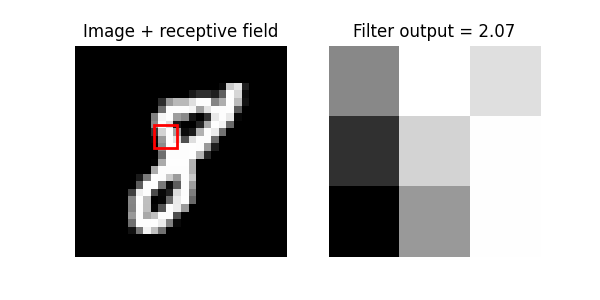

interactive(children=(IntSlider(value=10, continuous_update=False, description='i', max=25), IntSlider(value=1…

<function __main__.conv_step(i=10, j=10)>

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from matplotlib.patches import Rectangle
from torchvision import datasets, transforms

# use the same "8" image from the MNIST dataset for this example
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
for idx in range(len(mnist)):
    image, label = mnist[idx]
    if label == 8:
        img = image.squeeze().numpy()
        break

# Beispiel-Edge-Filter
kernel = np.array([
    [-1,0,1],
    [-1,0,1],
    [-1,0,1]
])

# Create the figure and artists once, then update them in-place
plt.ioff()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
ax_img, ax_patch = axes

im_main = ax_img.imshow(img, cmap='gray')
rect = Rectangle((10, 10), 3, 3, fill=False, color='red', linewidth=2)
ax_img.add_patch(rect)
ax_img.set_title('Image + receptive field')
ax_img.axis('off')

initial_patch = img[10:13, 10:13]
im_patch = ax_patch.imshow(initial_patch, cmap='gray')
ax_patch.set_title(f"Filter output = {np.sum(initial_patch * kernel):.2f}")
ax_patch.axis('off')

plt.show()

# Update function (does not recreate the figure)
def conv_step(i=10, j=10):
    patch = img[i:i+3, j:j+3]
    value = np.sum(patch * kernel)

    # move rectangle and update small patch image
    rect.set_xy((j, i))
    im_patch.set_data(patch)
    ax_patch.set_title(f"Filter output = {value:.2f}")

    # redraw the figure (widget backend updates in-place)
    try:
        fig.canvas.draw()
        fig.canvas.flush_events()
    except Exception:
        # fallback for non-widget backends
        from IPython.display import clear_output, display
        clear_output(wait=True)
        display(fig)

# interactive sliders wired to the in-place updater
i_slider = IntSlider(min=0, max=25, value=10, continuous_update=False)
j_slider = IntSlider(min=0, max=25, value=10, continuous_update=False)
interact(conv_step, i=i_slider, j=j_slider)


What we can observe is that the different kernels enhance different features of the image e.g. the horizontal or vertical edges of the image. The effect on the image is controlled by the weights of the elements of the kernel. 

## Convolutional layers
If we think about a learning based approach we can instead of using predetermined filter weights treat the weights as learnable parameters $\theta$ which we learn for a given classification task. Therefore we can construct a convolutional layer consisting of multiple convolutional kernels/ filters. This is called a convolutional layer. The hyperparameters of such a layer are the kernel size, the number of kernels the stride (do we apply the kernel step by step over the input or make bigger steps), the padding (do we enhance the edges of the image such that we apply the kernel on the first pixel or start further inside), dilation (do we have a dense or wide pixel grid in the input). For details see https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md and https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html 


The convolutional filters can be seen as local filters which are applied to a subset of the input pixels and make use of the local structures and patterns in images to construct local features in images. 
### 1. Local Receptive Fields

In a convolutional neural network (CNN), each neuron in a convolutional layer is connected only to a **small local region of the input image**, rather than to all input pixels. This small region is called the **receptive field**.

For example, a $3 \times 3$ filter only looks at **9 neighboring pixels at a time** when computing an output value.

Mathematically, the convolution operation can be written as:

$$
y_{i,j} = \sum_{u,v} w_{u,v} \, x_{i+u, j+v}
$$

This means the output at position $(i,j)$ depends only on a **local patch of the input image**.

**Comparison to Fully Connected Layers**

In a fully connected layer, every neuron is connected to **all input pixels**:

$$
y = Wx + b
$$

For example, with a $28 \times 28$ image, a single neuron depends on **784 input values**.  
In contrast, a CNN neuron with a $3 \times 3$ filter depends on only **9 pixels**.

This design leverages the fact that **important image structures (edges, corners, textures) are usually local patterns**.

---

### 2. Weight Sharing

In a convolutional layer, the **same filter (set of weights)** is applied across the entire image. This means the same weights are reused at every spatial location.

For example, a $3 \times 3$ filter detecting vertical edges is applied to every possible $3 \times 3$ patch in the image.

This property is called **weight sharing** because the parameters of the filter are shared across all spatial locations.

**Advantages**

- The model learns to detect the **same feature anywhere in the image**.
- The number of parameters is drastically reduced.

**Comparison to Fully Connected Layers**

Fully connected layers use **different weights for every input-output connection**, which leads to a very large number of parameters.

Example:

- Fully connected layer: $784 \times 256 \approx 200{,}000$ parameters  
- Convolutional layer with 32 filters of size $3 \times 3$:  
  $32 \times 3 \times 3 = 288$ parameters

Weight sharing therefore makes CNNs **much more parameter-efficient** and reduces the risk of overfitting.

---

### 3. Translational Invariance

Translational invariance means that a CNN can recognize a feature **regardless of where it appears in the image**.

Since the same filters are applied across the entire image (weight sharing), a feature such as an edge or shape will activate the same filter **whether it appears on the left, right, top, or bottom of the image**.

This property allows CNNs to be robust to **small shifts or translations of objects**.

**Example**

A handwritten digit "3" in an image may appear slightly shifted to the left or right.  
A CNN can still detect the same features because the filters scan the entire image.

**Comparison to Fully Connected Layers**

Fully connected networks do not naturally handle translations.  
If an object moves to a different location in the image, the network must **learn separate weights for each possible position**, which requires more parameters and more training data.

CNNs handle this more efficiently because **the same filters detect the same patterns everywhere in the image**.

### Convolutional Layer – Summary

A **convolutional layer** extracts local features from an image by applying several small filters (kernels) that slide across the image.

---

### Convolution Operation

Each filter is a small matrix (e.g. $3 \times 3$ or $5 \times 5$) that is applied to small patches of the input image.  
The filter is moved across the image, and at each position a weighted sum of the local pixels is computed.

Mathematically, the convolution at position $(i,j)$ is

$$
y_{i,j} = \sum_{u,v} w_{u,v}\,x_{i+u,j+v} + b
$$

where

- $x$ is the input image  
- $w$ are the filter weights  
- $b$ is a bias term

This operation detects **local patterns** such as edges, corners, or textures.

---

### Multiple Filters and Feature Maps

A convolutional layer usually contains **many filters** (e.g. 32, 64, or 128).  
Each filter learns to detect a different type of feature.

Every filter produces one **feature map**, which represents where that feature appears in the image.

Example:

Input image

$$
1 \times 28 \times 28
$$

Convolution with **32 filters of size $3 \times 3$**

Output

$$
32 \times 26 \times 26
$$

Properties:

- the **spatial size decreases** (depending on kernel size, stride, and padding)
- the **number of channels increases** because each filter produces its own feature map

---

### Activation Function (ReLU)

After the convolution, a nonlinear activation function is applied elementwise to the feature maps.

The most common activation is **ReLU**:

$$
\text{ReLU}(x) = \max(0,x)
$$

This means

- positive values remain unchanged
- negative values are set to zero

ReLU introduces **nonlinearity**, which allows the network to learn complex patterns.

---

### Typical Convolutional Layer Pipeline

A convolutional block usually follows this structure:

$$
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{ReLU}
$$

or more commonly in modern architectures:

$$
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{BatchNorm} \rightarrow \text{ReLU}
$$

---

### Key Ideas

A convolutional layer works by

- applying **small local filters**
- **sliding them across the image**
- producing multiple **feature maps**
- applying **ReLU activation** to introduce nonlinearity

This allows CNNs to efficiently learn **hierarchical visual features**, starting from simple edges and building up to complex shapes and objects.

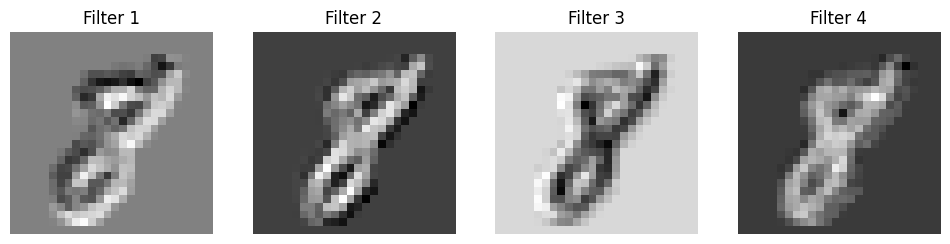

Number of parameters in the convolutional layer: 36


In [41]:
# lets implement a simple convolutional layer from scratch and visualize the feature maps after applying the convolutional layer to the image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
%matplotlib inline
# use the same "8" image from the MNIST dataset for this example
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
for idx in range(len(mnist)):
    image, label = mnist[idx]
    if label == 8:
        img = image.squeeze().numpy()
        break
# Define a simple convolutional layer
class SimpleConvLayer:
    def __init__(self, num_filters=4, filter_size=3):
        self.num_filters = num_filters
        self.filter_size = filter_size
        # Initialize random filters
        self.filters = np.random.randn(num_filters, filter_size, filter_size)

    def convolve(self, image):
        h, w = image.shape
        output = np.zeros((self.num_filters, h - self.filter_size + 1, w - self.filter_size + 1))
        for f in range(self.num_filters):
            for i in range(h - self.filter_size + 1):
                for j in range(w - self.filter_size + 1):
                    patch = image[i:i+self.filter_size, j:j+self.filter_size]
                    output[f, i, j] = np.sum(patch * self.filters[f])
        return output
# Create a convolutional layer and apply it to the image
conv_layer = SimpleConvLayer(num_filters=4, filter_size=3)
feature_maps = conv_layer.convolve(img)
# Visualize the feature maps
fig, axes = plt.subplots(1, conv_layer.num_filters, figsize=(12, 3))
for i in range(conv_layer.num_filters):
    axes[i].imshow(feature_maps[i], cmap='gray')
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')
plt.show()

# now print the number of parameters in the convolutional layer and compare it to the number of parameters in a fully connected layer with the same number of filters and filter size
# Number of parameters in the convolutional layer
num_params_conv = conv_layer.num_filters * conv_layer.filter_size * conv_layer.filter_size
print(f'Number of parameters in the convolutional layer: {num_params_conv}')

The different filters of the  convolutional layer learned different image features like different intensities or different edges. The parameter count is with 36 low compared to the fully connected layers we had before. The total number of parameters is the 4 filters/ channels we have in the layer times the kernel size of 3x3. Often an additional bias term per filter is added this would result in 4x3x3 + 4 = 40 as total parameter count. 
## Pooling Layer
After the convolution layer is applied to the input in modern CNN model architectures a pooling layer is followed. This layer applies to each nxn non overlapping block per filter a function. Typical is a 2x2 max pooling. Here the maximum pixel per 2x2 window per channel will be forwarded to the next covnolutional layer. The pooling operation therefore is a method to shrink the dimensions of large images into smaller summary images. 
## Deep CNN Model for MNist
As we now know the building blocks of CNN models we can build a multi convolutional layer model to predict the handwritten digits but instead using a FCN we now implement it using a CNN.

Epoch [1/20], Loss: 0.3940
Validation Loss: 0.1174, Accuracy: 96.53%
Epoch [2/20], Loss: 0.1179
Validation Loss: 0.0680, Accuracy: 98.01%
Epoch [3/20], Loss: 0.0828
Validation Loss: 0.0521, Accuracy: 98.46%
Epoch [4/20], Loss: 0.0646
Validation Loss: 0.0485, Accuracy: 98.42%
Epoch [5/20], Loss: 0.0526
Validation Loss: 0.0406, Accuracy: 98.75%
Epoch [6/20], Loss: 0.0443
Validation Loss: 0.0438, Accuracy: 98.64%
Epoch [7/20], Loss: 0.0390
Validation Loss: 0.0493, Accuracy: 98.40%
Epoch [8/20], Loss: 0.0335
Validation Loss: 0.0354, Accuracy: 98.78%
Epoch [9/20], Loss: 0.0302
Validation Loss: 0.0326, Accuracy: 98.92%
Epoch [10/20], Loss: 0.0248
Validation Loss: 0.0403, Accuracy: 98.75%
Epoch [11/20], Loss: 0.0224
Validation Loss: 0.0359, Accuracy: 98.91%
Epoch [12/20], Loss: 0.0209
Validation Loss: 0.0354, Accuracy: 98.79%
Epoch [13/20], Loss: 0.0178
Validation Loss: 0.0282, Accuracy: 99.07%
Epoch [14/20], Loss: 0.0162
Validation Loss: 0.0313, Accuracy: 99.04%
Epoch [15/20], Loss: 0.0135
V

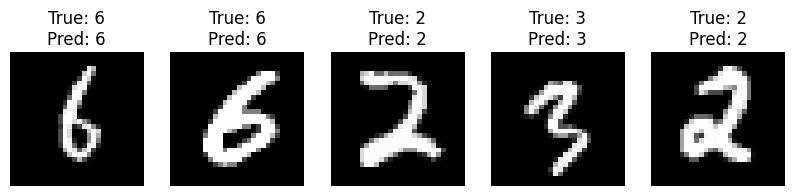

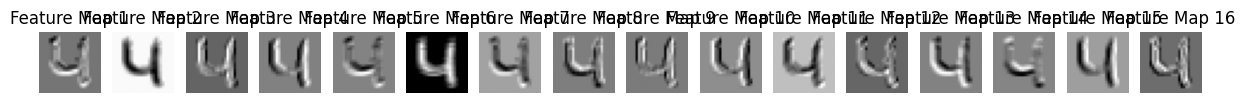

In [43]:
# Implement a CNN model for MNIST classification
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a simple CNN model for MNIST classification
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)  # 16 filters of size 3x3
        self.pool = nn.MaxPool2d(2, 2)  # max pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)  # 32 filters of size 3x3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)  # 64 filters of size 3x3
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(64 * 1 * 1, 128)  # fully connected layer (use adaptive pooling output)
        self.fc2 = nn.Linear(128, 10)  # output layer for 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv1 + relu + pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 + relu + pool
        x = F.relu(self.conv3(x))  # conv3 + relu
        x = self.adaptive_pool(x)  # adaptive pool to fixed 1x1 output
        x = x.view(-1, 64 * 1 * 1)  # flatten the feature maps
        x = F.relu(self.fc1(x))  # fully connected layer + relu
        x = self.fc2(x)  # output layer 
        x = F.log_softmax(x, dim=1)  # apply log softmax to the output
        return x
    

# Lets train this model on the MNIST dataset
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.NLLLoss()  # negative log likelihood loss for classification --> because we applied log softmax in the output layer
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer for training
num_epochs = 20

for epoch in range(num_epochs):
    model.train()  # set the model to training mode
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # move data to the device (GPU or CPU)
        optimizer.zero_grad()  # zero the parameter gradients
        outputs = model(images)  # forward pass
        loss = criterion(outputs, labels)  # compute the loss
        loss.backward()  # backward pass
        optimizer.step()  # update the weights
        running_loss += loss.item() * images.size(0)  # accumulate the loss

    epoch_loss = running_loss / len(train_loader.dataset)  # average loss for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

    # Validation phase
    model.eval()  # set the model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # disable gradient calculation for validation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = 100.0 * correct / total if total > 0 else 0.0
    print(f'Validation Loss: {val_loss / len(test_loader.dataset):.4f}, Accuracy: {val_acc:.2f}%')
    
# Show final performance of the model on the test set
model.eval()  # set the model to evaluation mode
vis_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)  # data loader for testing with a mini/batch of size 5
with torch.no_grad():  # disable gradient calculation for testing
    for images, labels in vis_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[i].set_title(f'True: {labels[i].item()}\nPred: {predicted[i].item()}')
            axes[i].axis('off')
        plt.show()
        break
    
# Now we will visualize the feature maps after the first convolutional layer for a sample image from the test set
# Get a sample image from the test set
model.eval()  # set the model to evaluation mode
with torch.no_grad():
    for images, labels in vis_loader:
        images, labels = images.to(device), labels.to(device)
        fmap = model.conv1(images)  # get the output of the first convolutional layer (before relu/pool)
        feature_maps = fmap.cpu().numpy()  # move the feature maps to CPU and convert to numpy array
        break  # only process one batch of test samples
# Visualize the feature maps
num_feature_maps = feature_maps.shape[1]  # number of feature maps (filters)
fig, axes = plt.subplots(1, num_feature_maps, figsize=(15, 3))
for i in range(num_feature_maps):
    axes[i].imshow(feature_maps[0, i], cmap='gray')  # visualize the feature map for the first image in the batch
    axes[i].set_title(f'Feature Map {i+1}')
    axes[i].axis('off')
plt.show()



## Data Augmentation

**Data augmentation** is a technique used to artificially increase the size and diversity of a training dataset by applying **random transformations** to the input images.  

Common transformations include:

- **Rotation** (small angles)
- **Translation / shifting**
- **Flipping** (horizontal or vertical)
- **Scaling / zooming**
- **Brightness or color adjustments**
- **Random cropping**

**Purpose:**  

- Reduces **overfitting** by exposing the model to varied versions of the same data  --> Comparable to ridge regression 
- Improves **generalization** to unseen data  
- Especially useful when the dataset is small
- Can be efficient integrated in mini batch SGD by adding transformations on the fly

## Pre-trained Models

**Pre-trained models** are neural networks that have been previously trained on large benchmark datasets (e.g., ImageNet) and can be **fine-tuned** or used as **feature extractors** for new tasks.

Advantages:

- **Faster training**: weights already capture general features like edges, textures, and shapes  
- **Better performance** on small datasets  
- **Transfer learning**: only the final layers may need retraining for a new task

Common pre-trained models in PyTorch:

- `resnet18`, `resnet50` (Residual Networks)  
- `vgg16`, `vgg19` (VGG Networks)  
- `densenet121` (DenseNet)  
- `mobilenet_v2` (MobileNet for lightweight applications)


This allows leveraging **general visual features** learned on large datasets for your specific classification task.